Data URL: https://universe.roboflow.com/storm07/facial-expression-detection-bldze

In [1]:
!nvidia-smi

Mon Apr 20 05:18:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 51.3 MB/s eta 0:00:00


In [3]:
import ultralytics
ultralytics.checks()

Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 42.9/112.6 GB disk)


In [4]:
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.9/175.9 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 71.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 72.6 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [1]:
from ultralytics import YOLO
from IPython.display import display, Image

In [ ]:
import roboflow
from roboflow import Roboflow
rf = Roboflow(api_key="****************")
project = rf.workspace("storm07").project("facial-expression-detection-bldze")
version = project.version(1)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Facial-Expression-Detection-1 in yolov11:: 100%|██████████| 3120/3120 [00:00<00:00, 8477.15it/s]


In [5]:
dataset.location

'/content/Facial-Expression-Detection-1'

In [6]:
!yolo task=detect mode=train data={dataset.location}/data.yaml model="yolo11n.pt" epochs=100 imgsz=640

Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Facial-Expression-Detection-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask

# Step 5: Examine Training Results

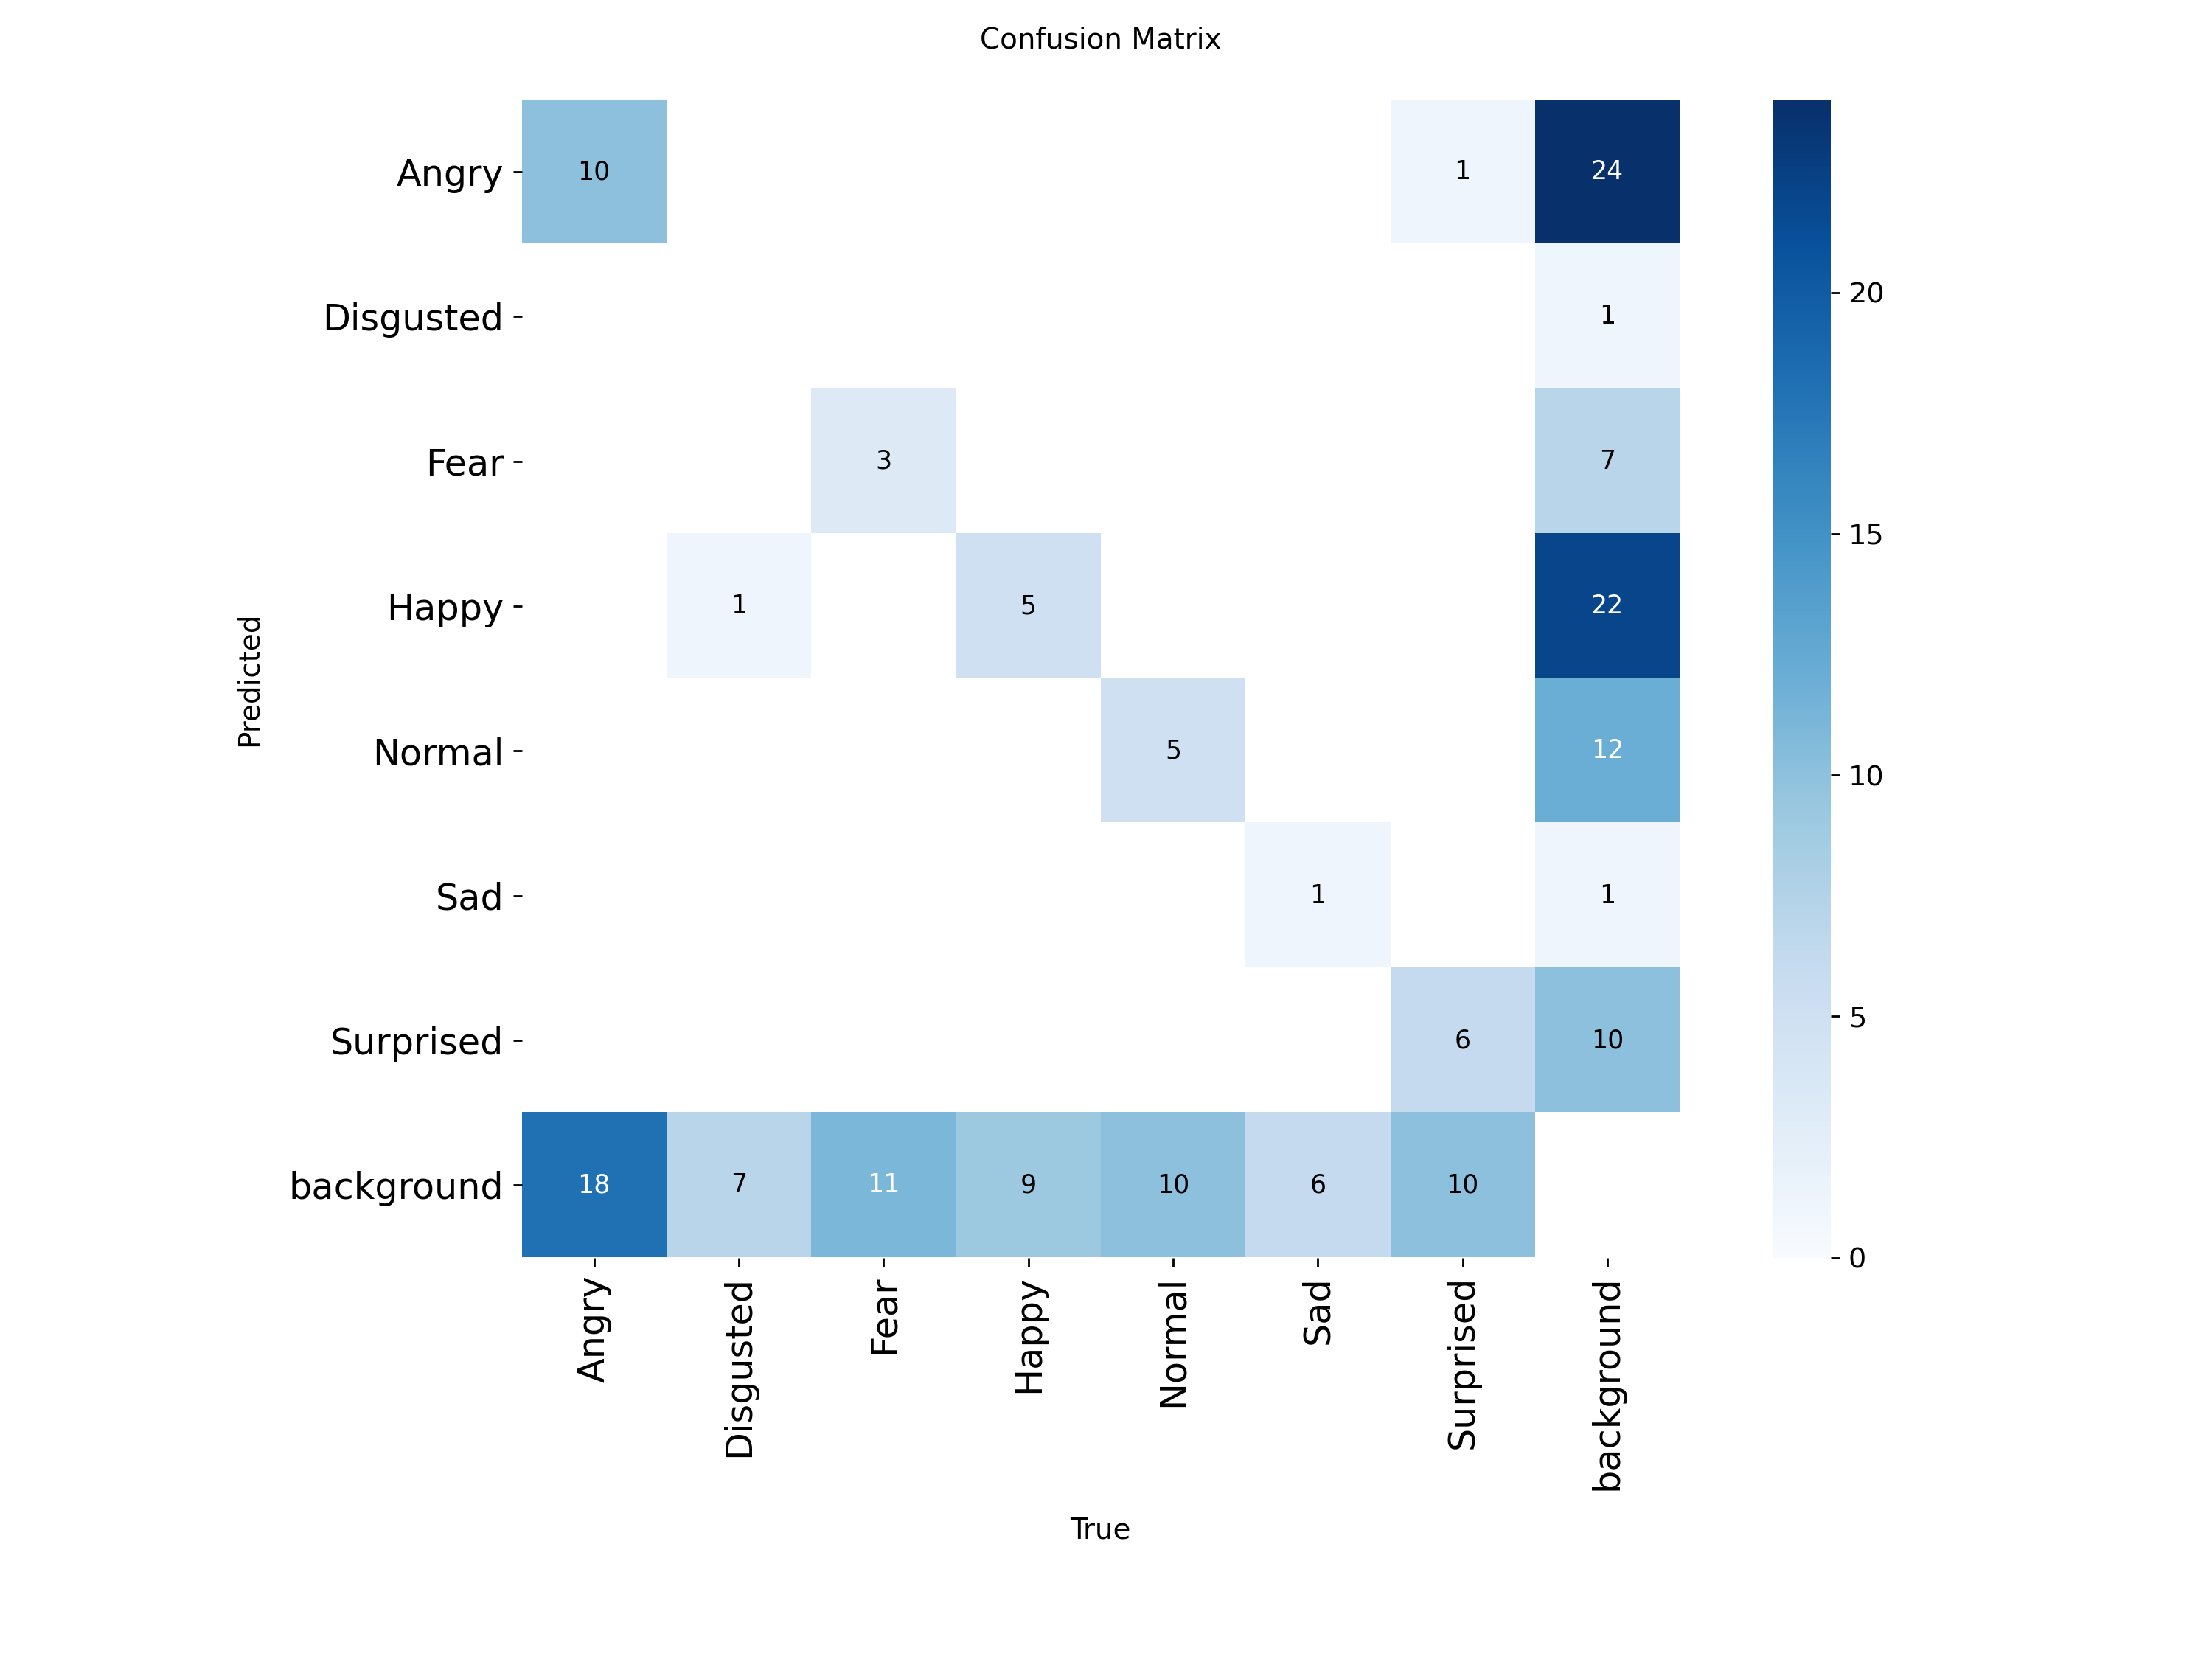

In [8]:
Image("/content/runs/detect/train/confusion_matrix.png", width=1000)

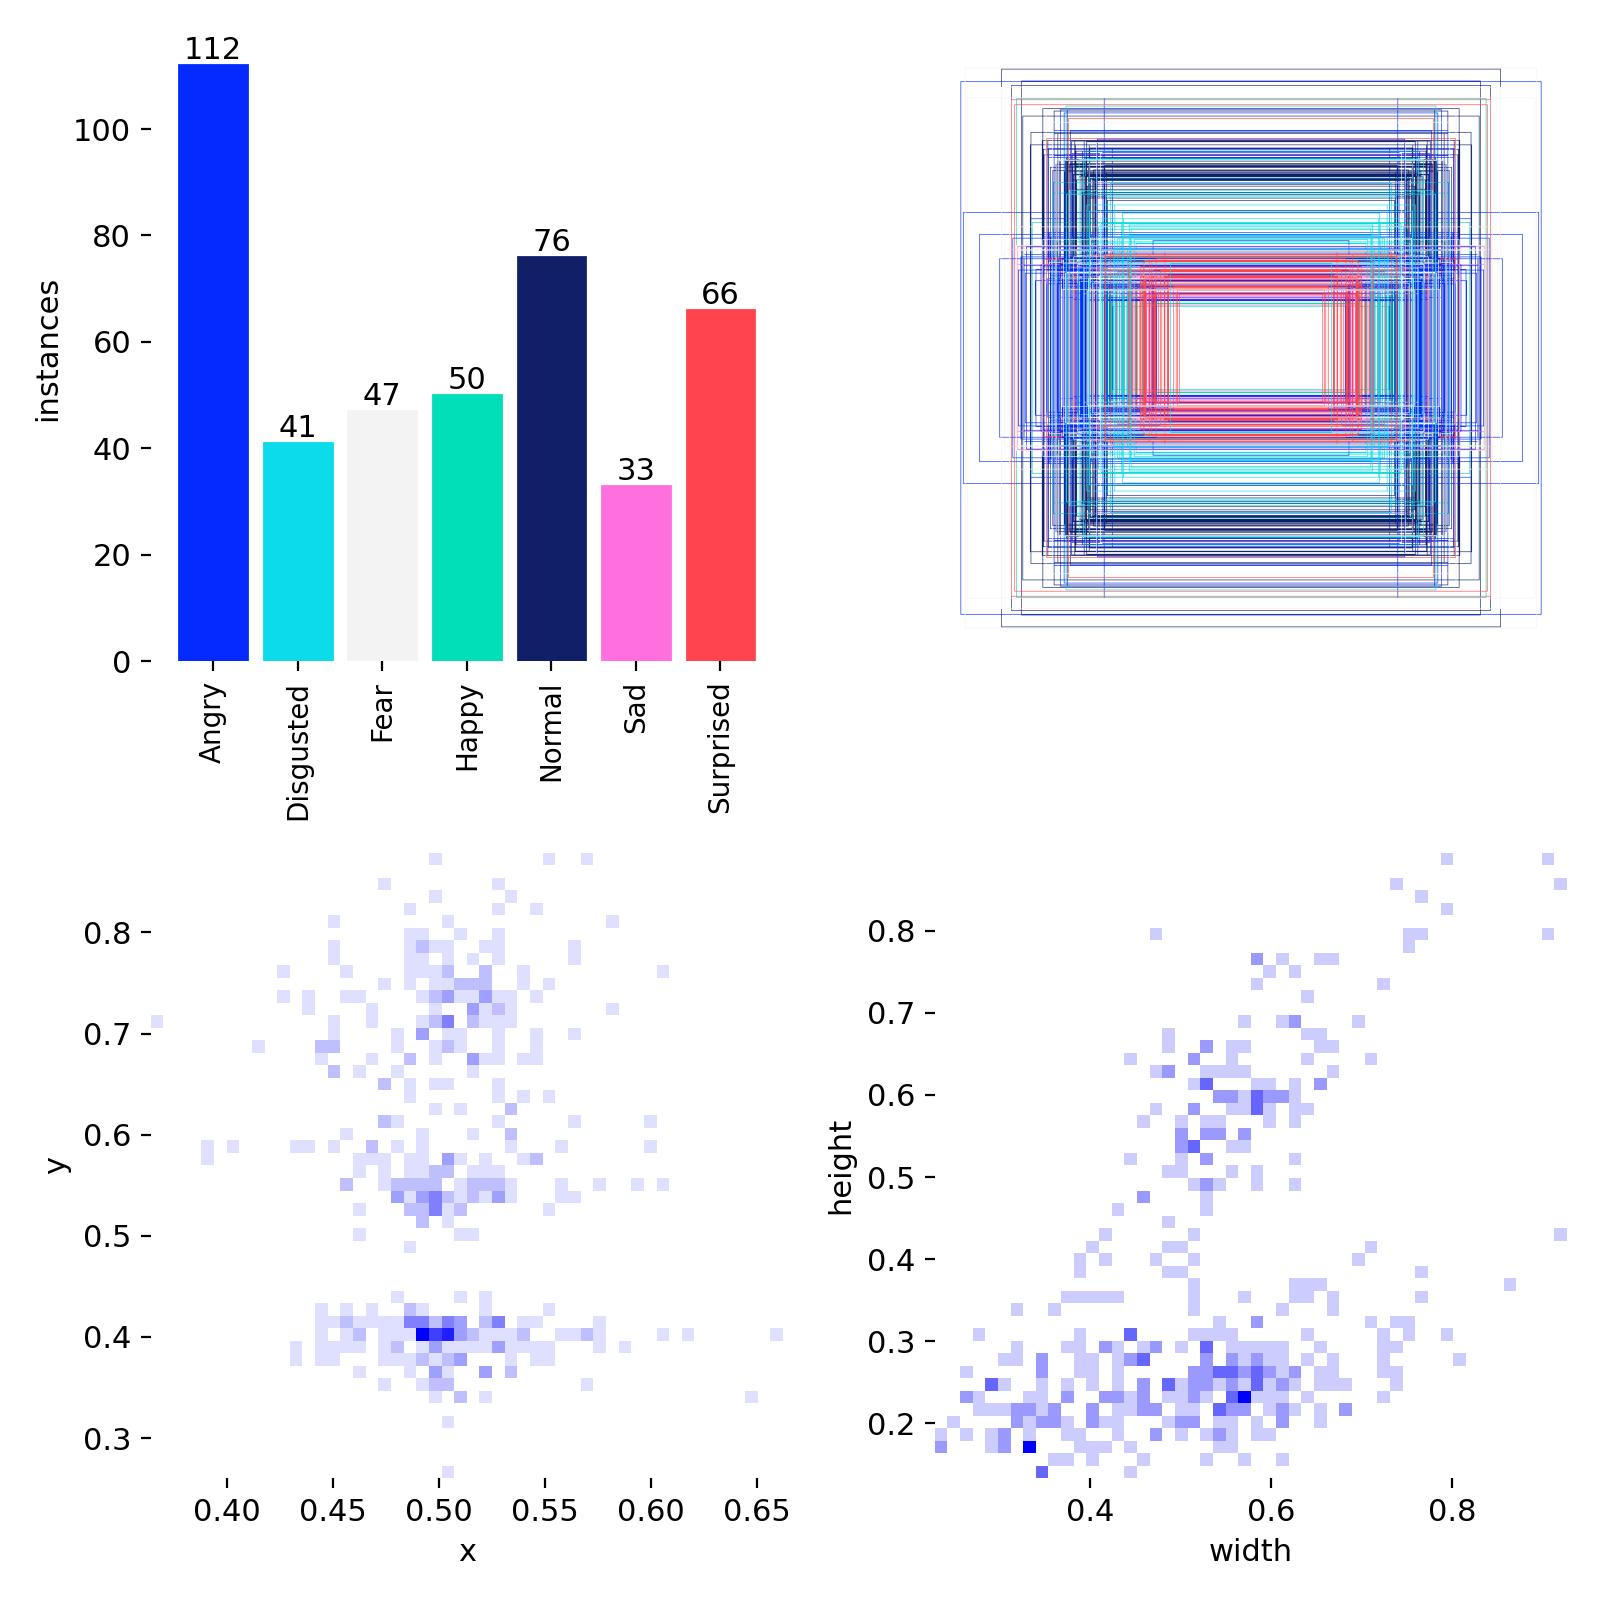

In [10]:
Image("/content/runs/detect/train/labels.jpg", width=600)

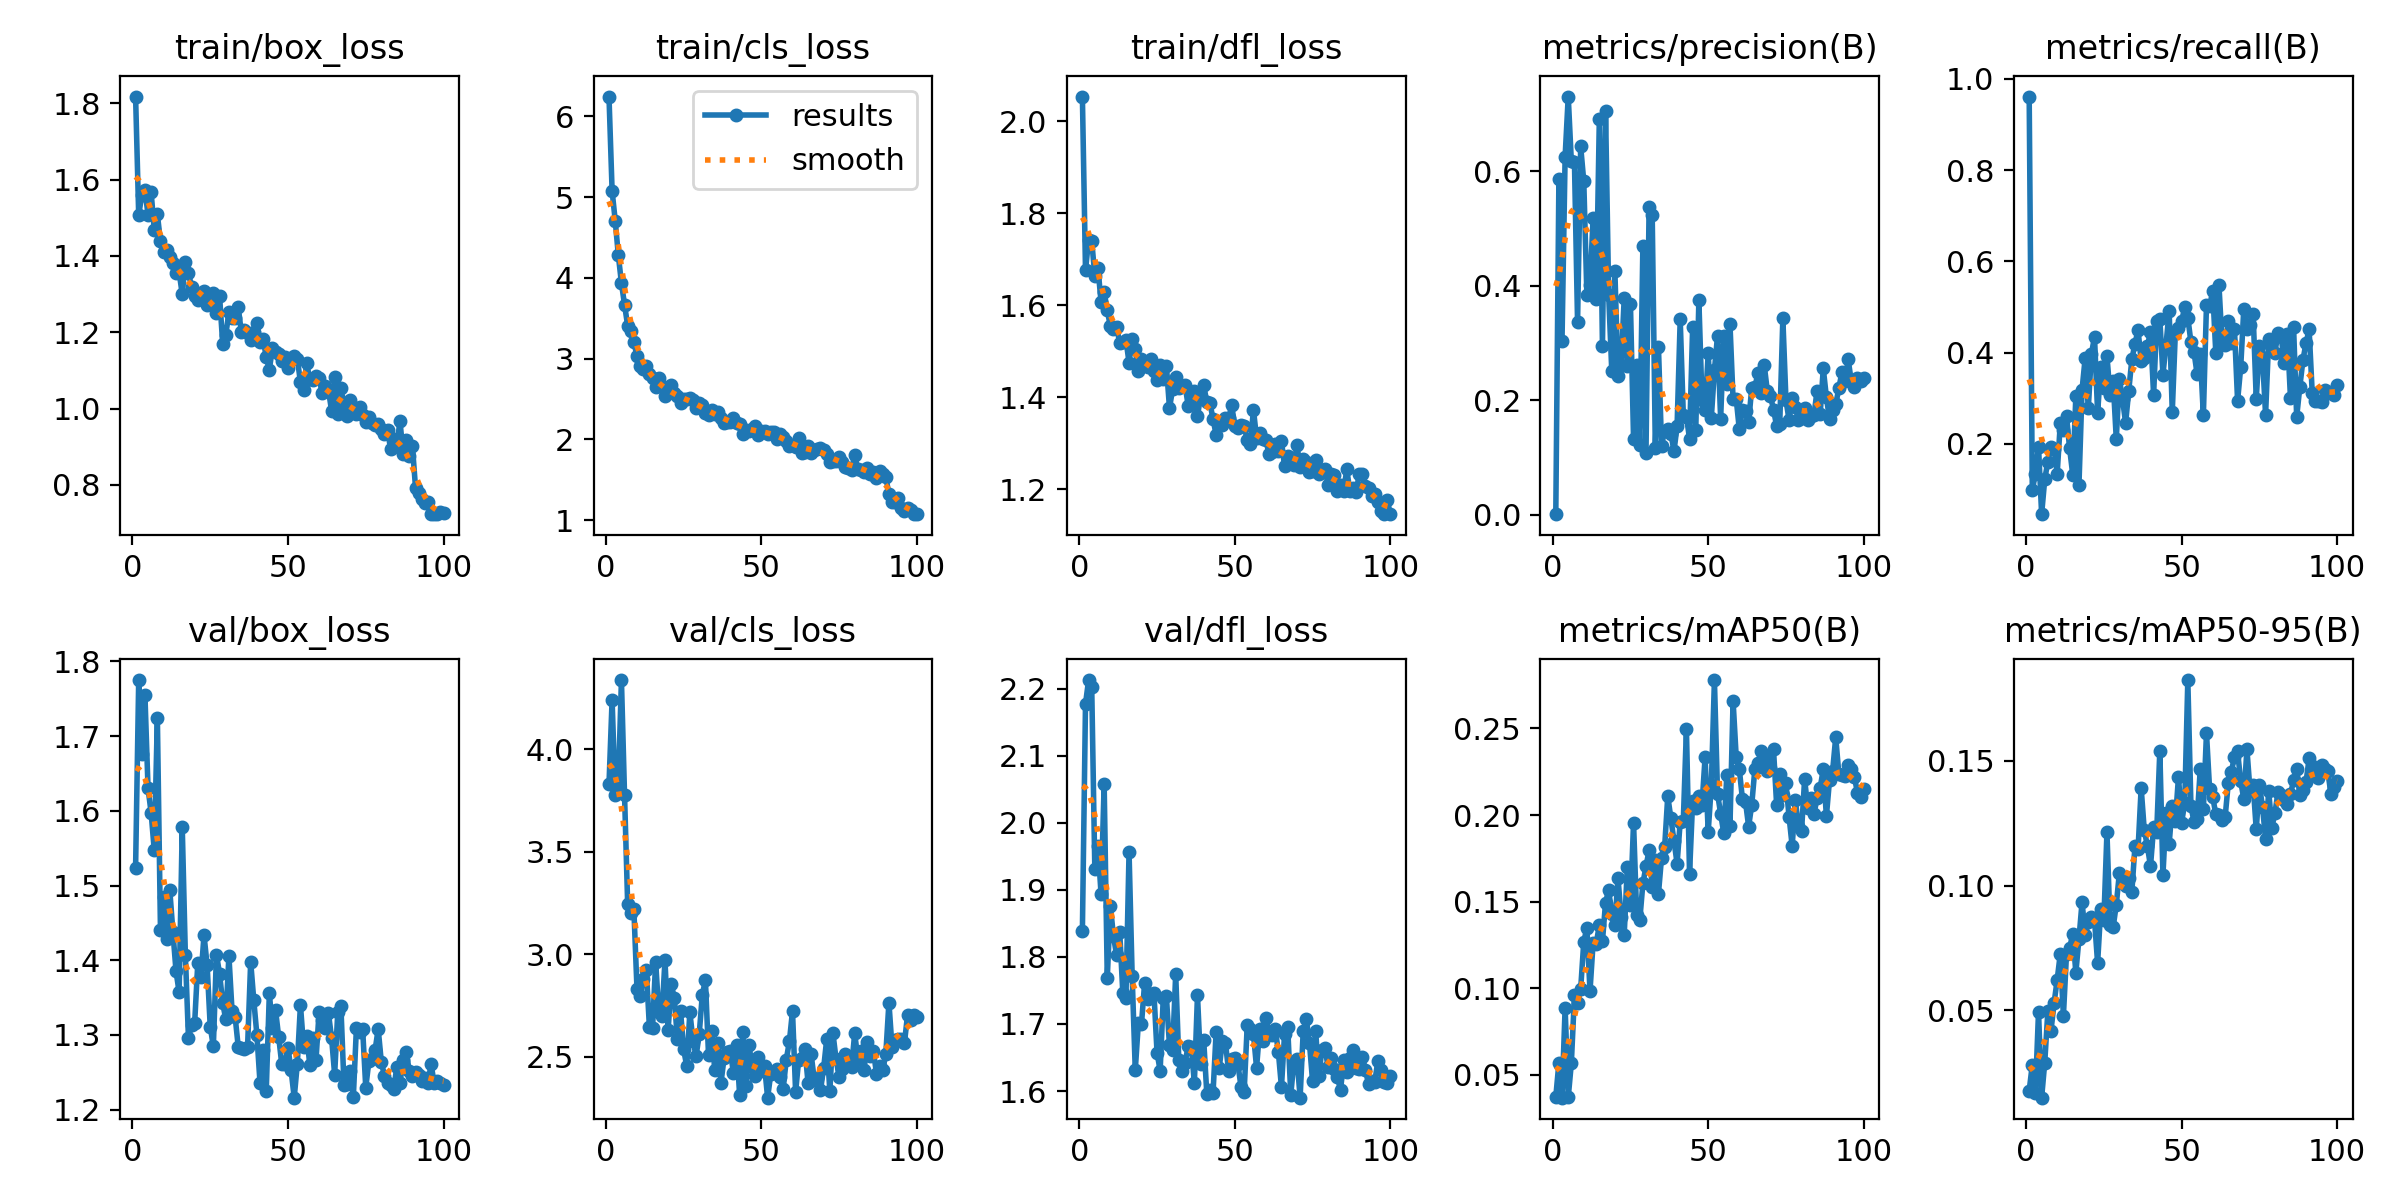

In [12]:
Image("/content/runs/detect/train/results.png", width=1000)

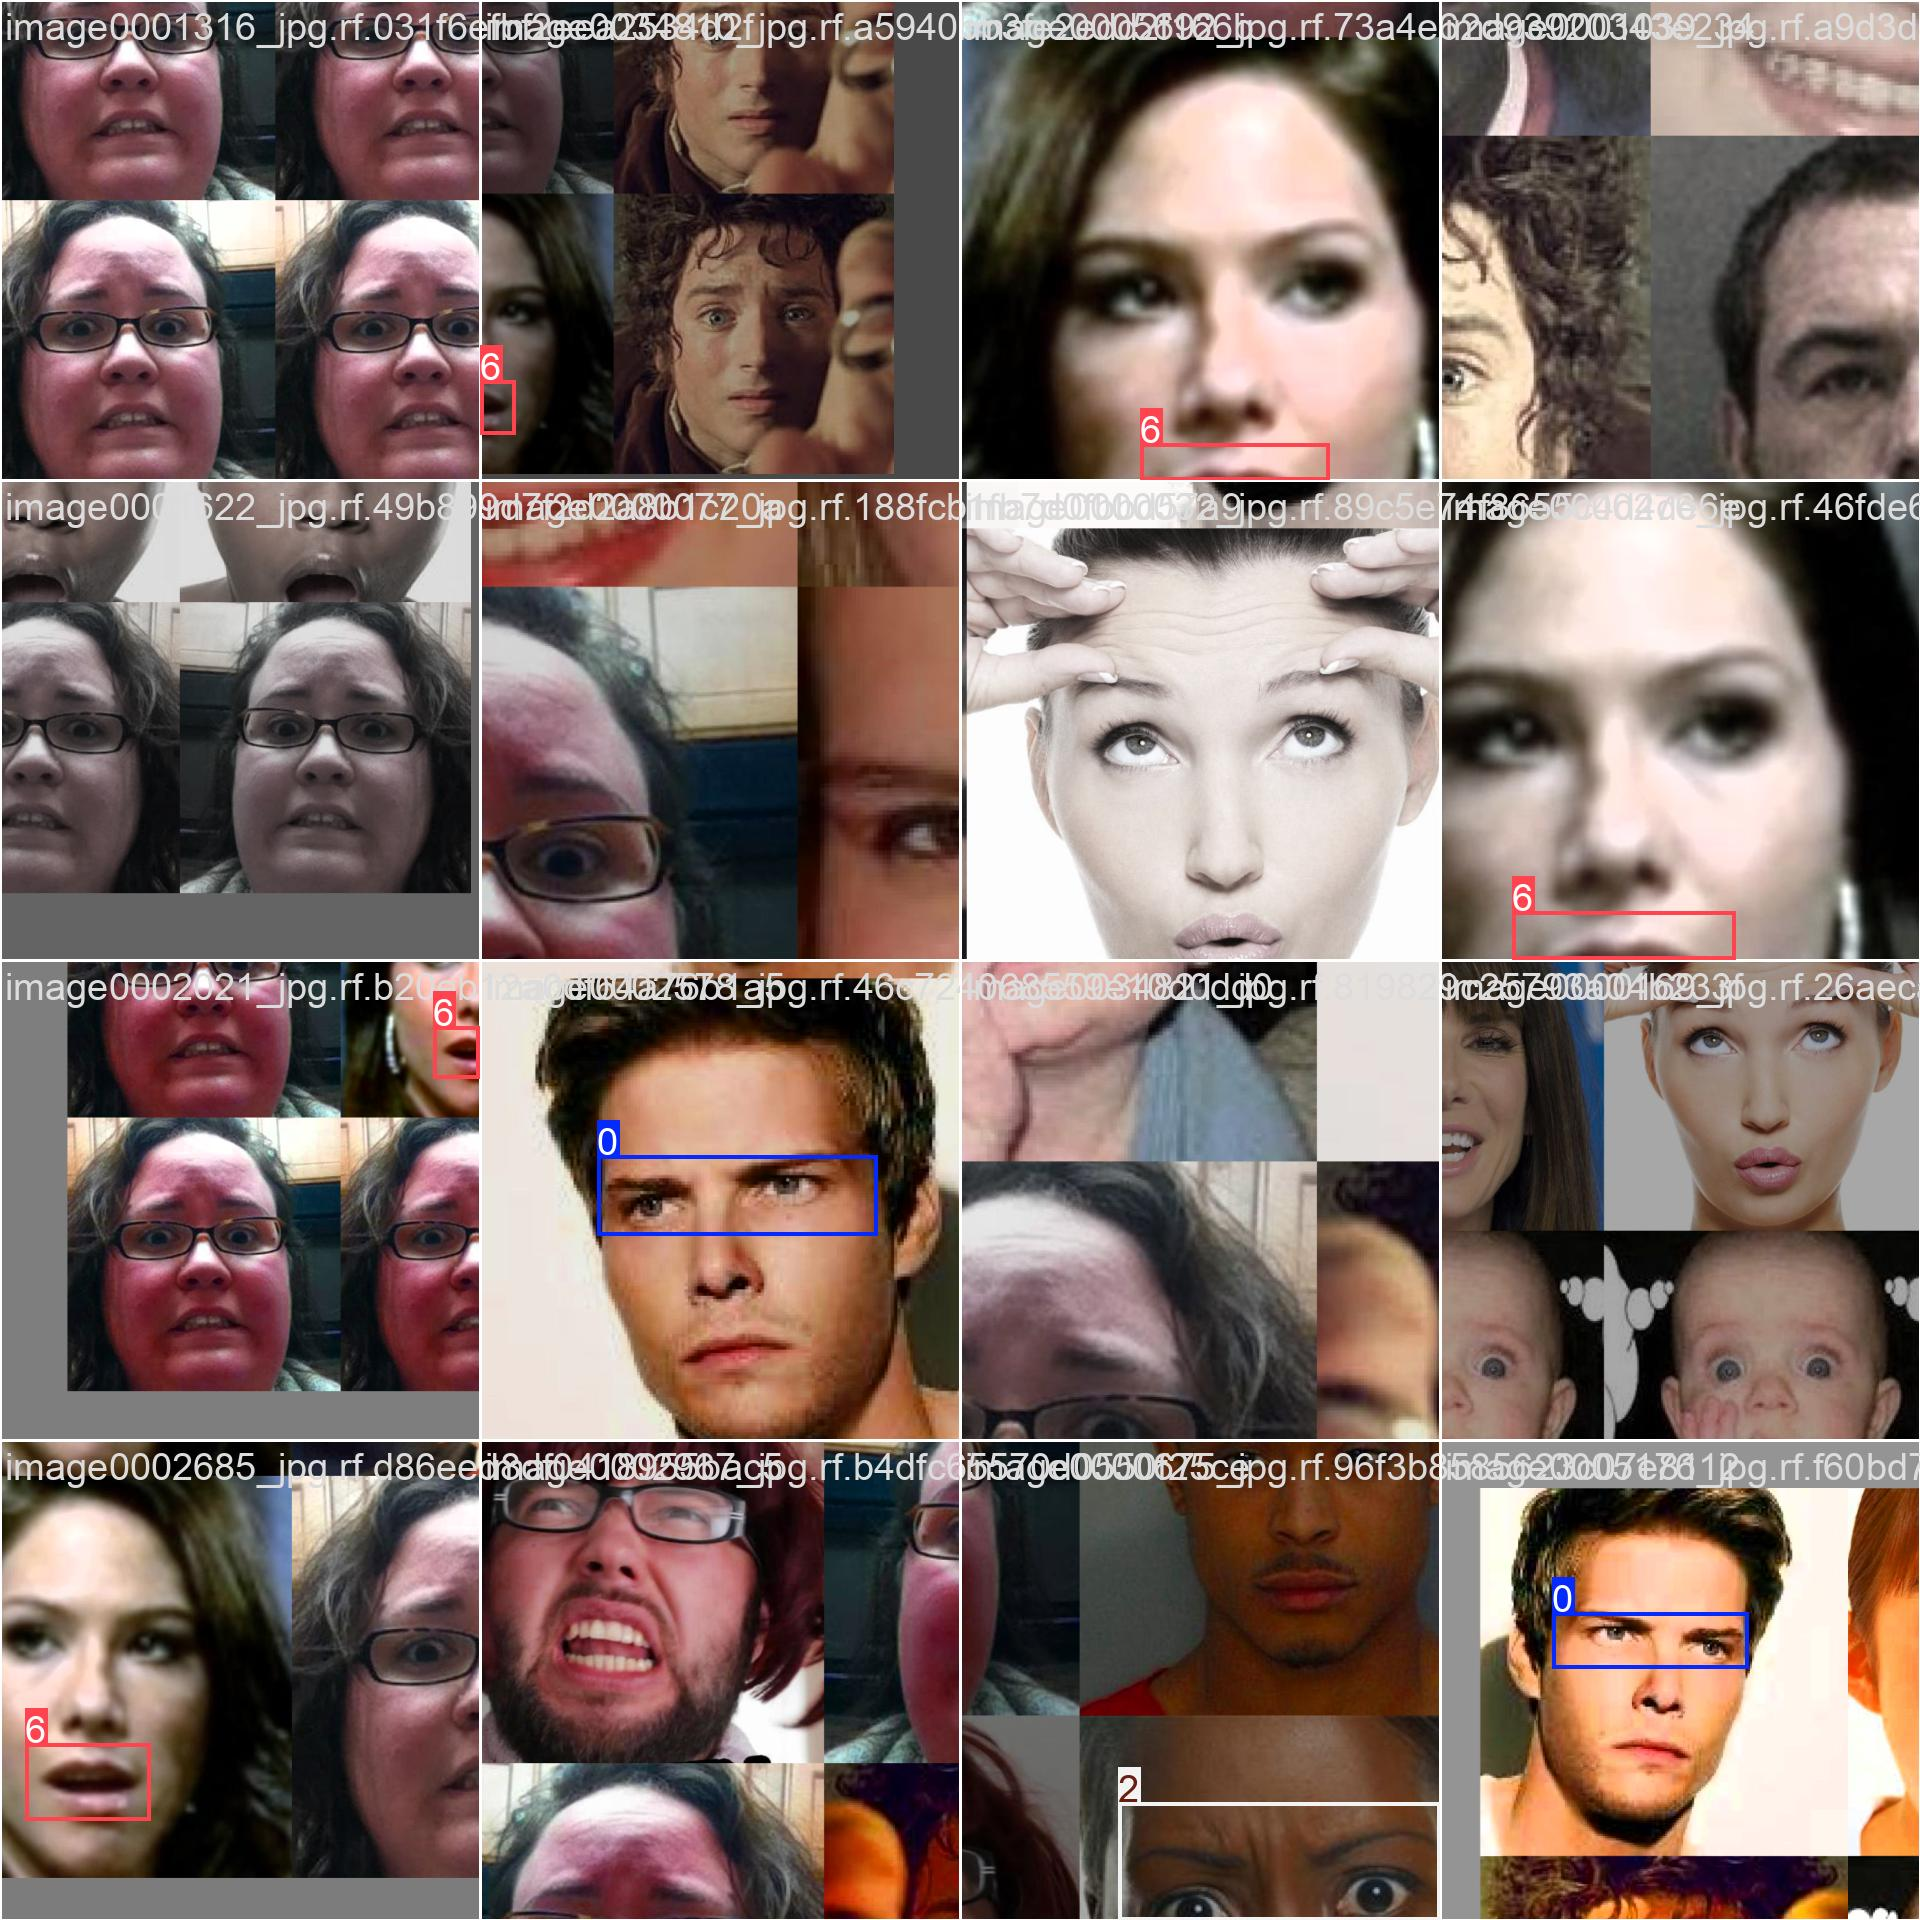

In [13]:
Image("/content/runs/detect/train/train_batch0.jpg", width=1000)

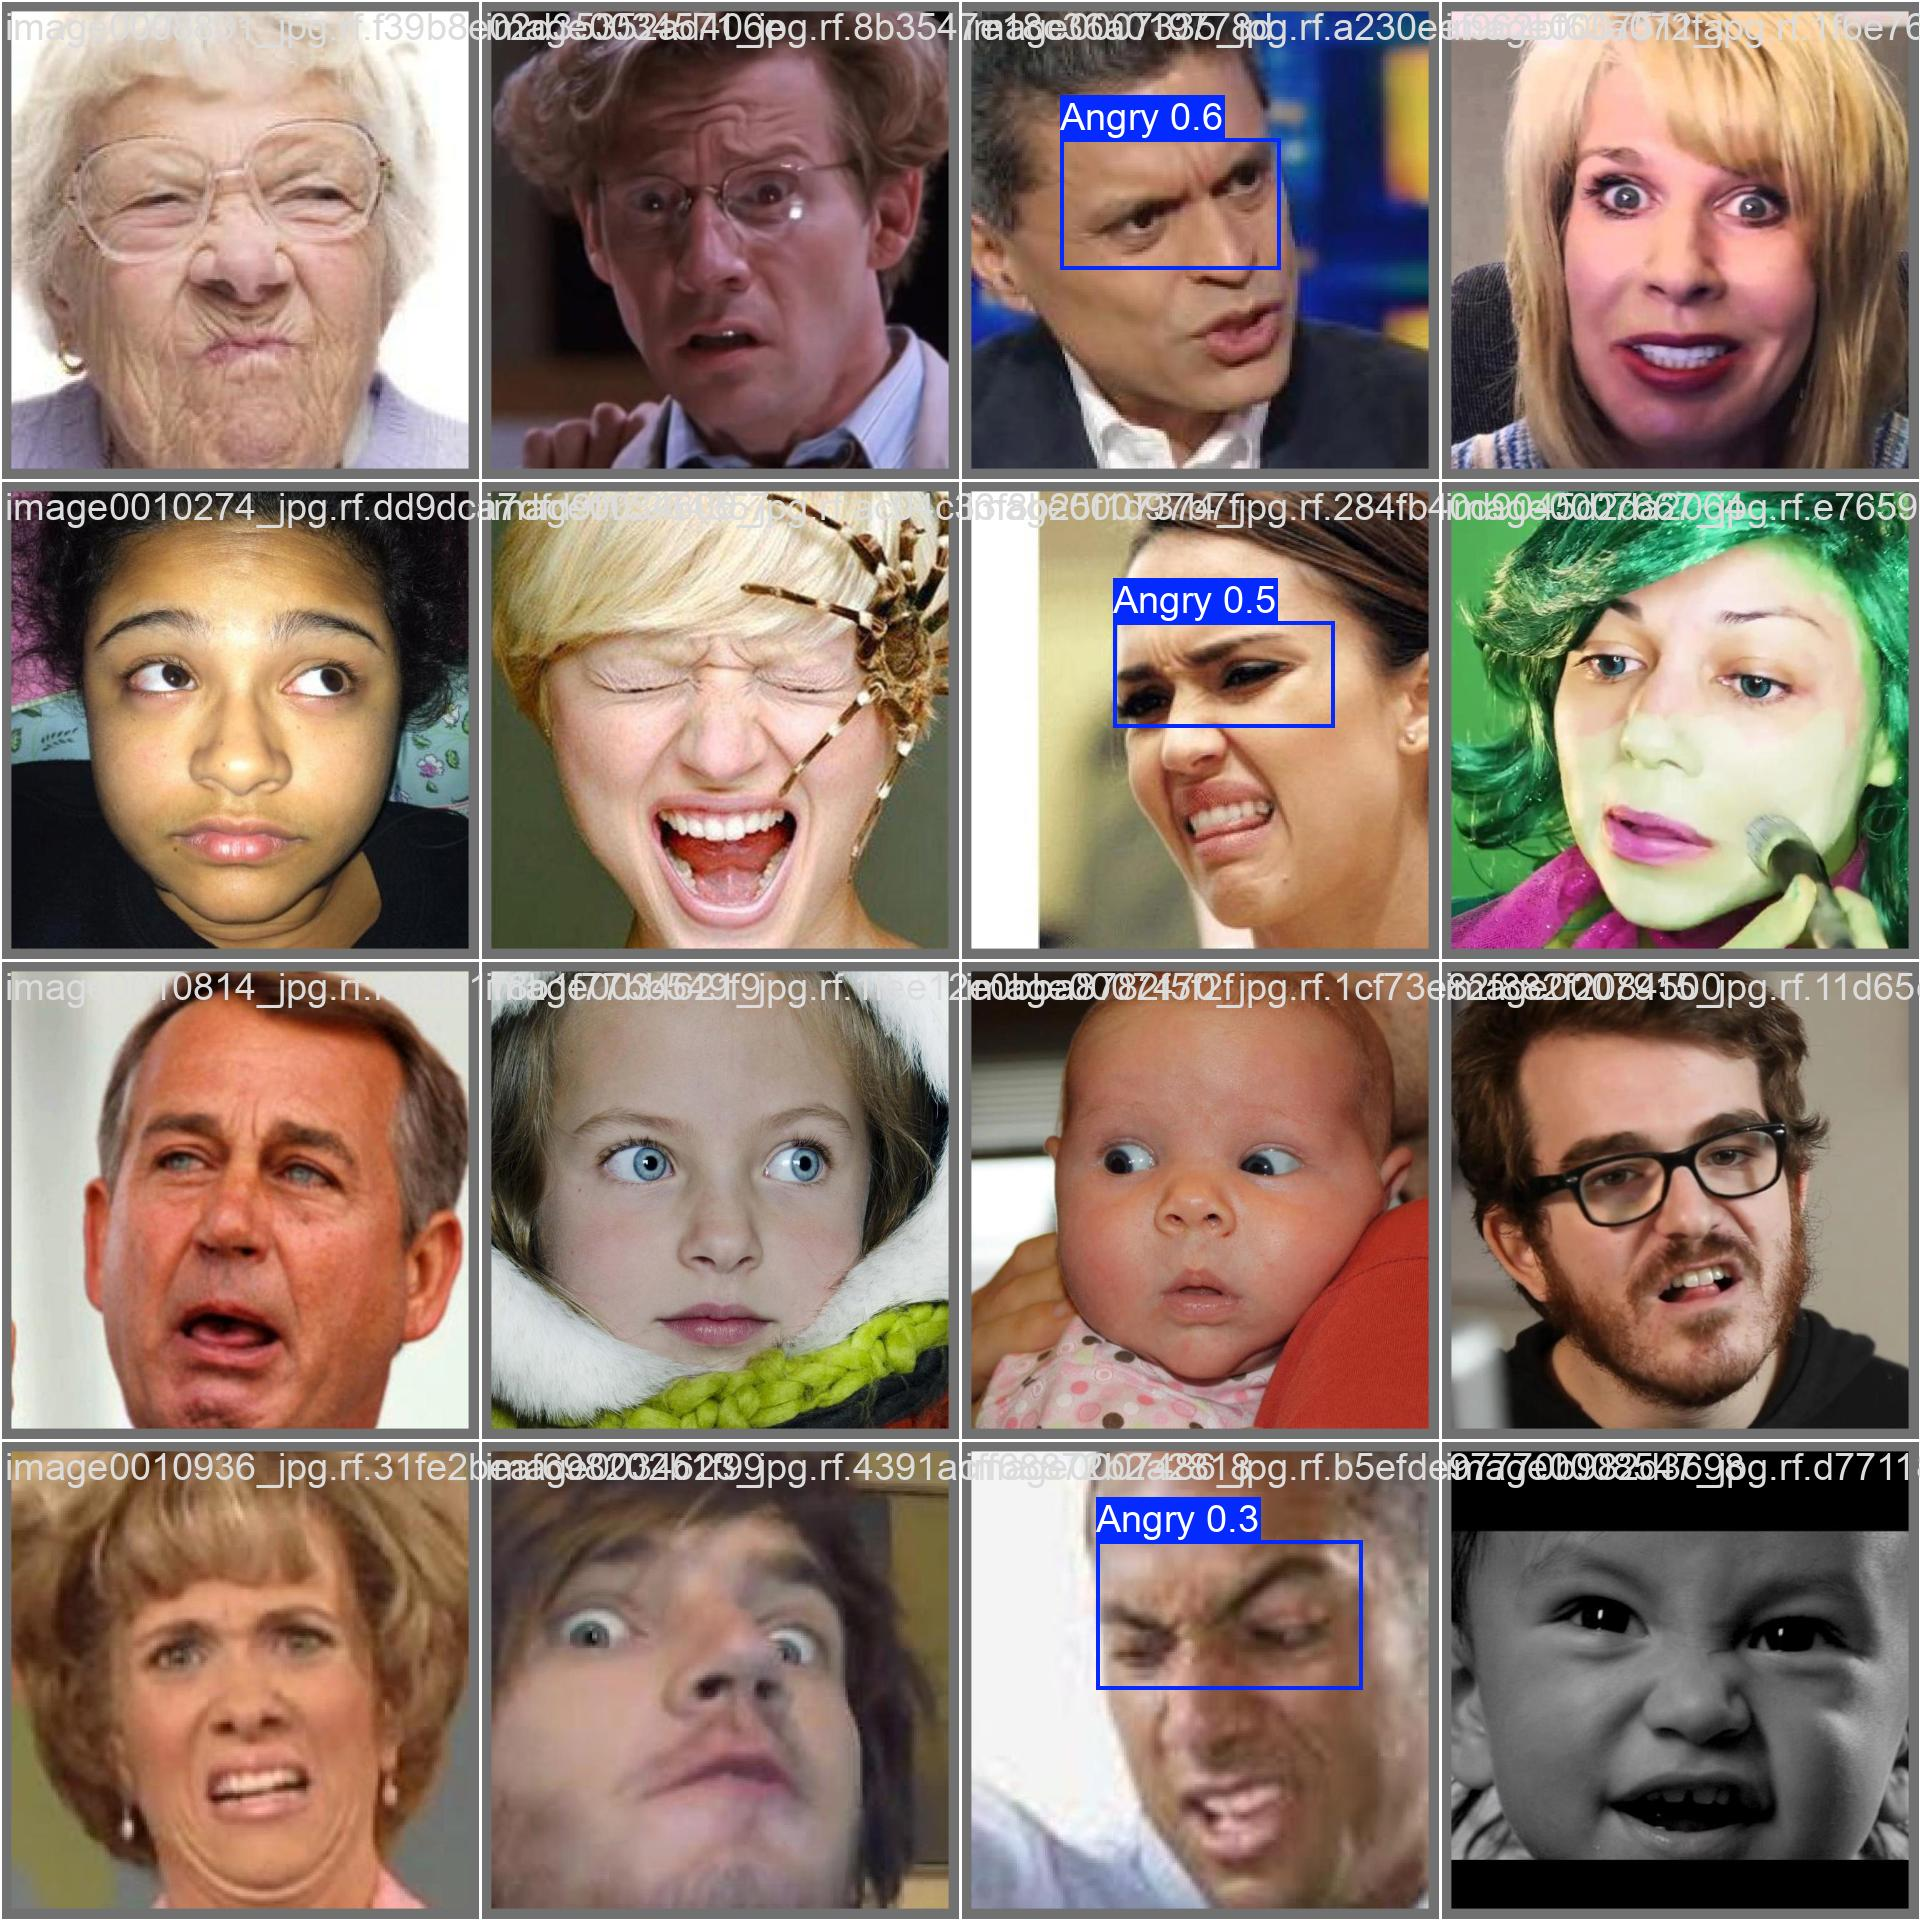

In [15]:
Image("/content/runs/detect/train/val_batch0_pred.jpg", width=600)

# Step: 07  Validate Fine-Tuned Model

In [17]:
!yolo task=detect mode=val model="/content/runs/detect/train/weights/best.pt" data={dataset.location}/data.yaml

Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,583,517 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1559.6±346.0 MB/s, size: 34.9 KB)
val: Scanning /content/Facial-Expression-Detection-1/valid/labels.cache... 312 images, 215 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 312/312 59.5Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 23, len(boxes) = 103. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 20/20 4.0it/s 4.9s
                   all        312        103      0.251      0.477      0.278      0.183
                 Angry         27         28      0.261        0.5      0.324      0.215
             Disgu

# Step:08 Inference with Custom Model on Images

In [18]:
!yolo task=detect mode=predict model="/content/runs/detect/train/weights/best.pt" conf=0.25 source={dataset.location}/test/images save=True

Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,583,517 parameters, 0 gradients, 6.3 GFLOPs

image 1/150 /content/Facial-Expression-Detection-1/test/images/image0000016_jpg.rf.cb50ac50ab950d3f783c7b7755a773d0.jpg: 640x640 1 Normal, 11.5ms
image 2/150 /content/Facial-Expression-Detection-1/test/images/image0000027_jpg.rf.0d60aff483e95efc79ffaff183d64570.jpg: 640x640 1 Angry, 8.1ms
image 3/150 /content/Facial-Expression-Detection-1/test/images/image0000028_jpg.rf.bf85600c6dc605682b26099e9ea109f4.jpg: 640x640 (no detections), 7.4ms
image 4/150 /content/Facial-Expression-Detection-1/test/images/image0000045_jpg.rf.0c782179a0c0b823d4e9b0ce251aaac2.jpg: 640x640 2 Happys, 9.2ms
image 5/150 /content/Facial-Expression-Detection-1/test/images/image0000048_jpg.rf.c112967633395a3a8123c45f33868528.jpg: 640x640 1 Normal, 7.7ms
image 6/150 /content/Facial-Expression-Detection-1/test/images/image0000058_jpg.rf.84673cdaac78aecaee

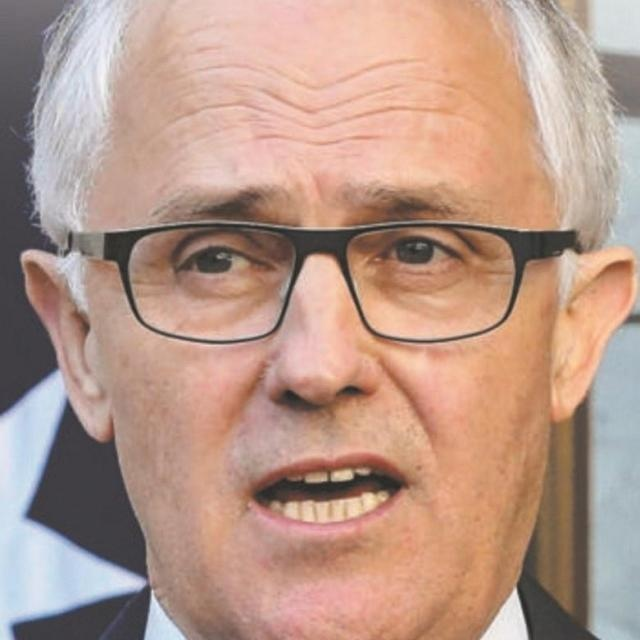

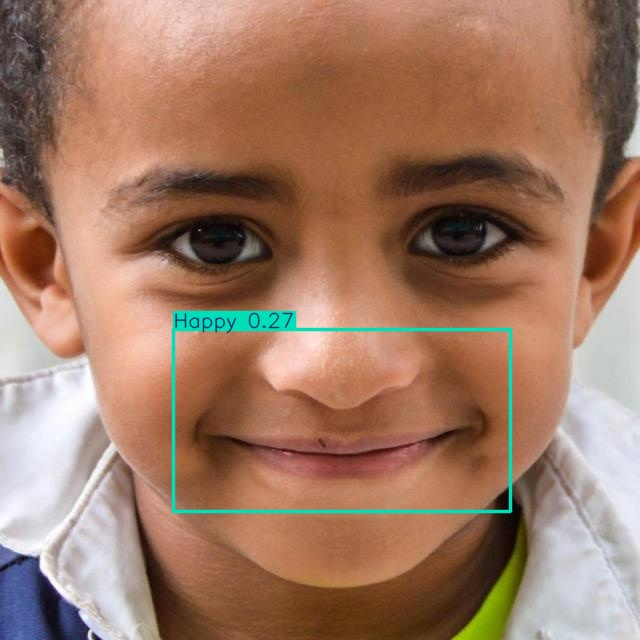

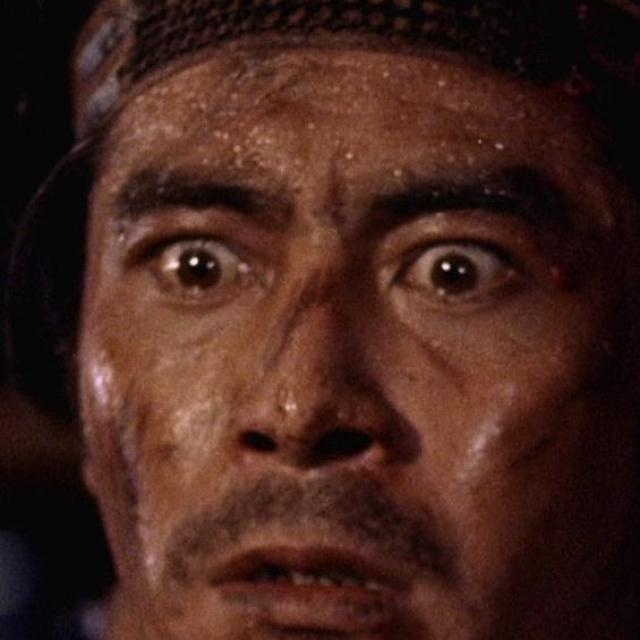

In [19]:
import glob
import os
from IPython.display import Image as IPyImage, display

latest_folder = max(glob.glob('/content/runs/detect/predict*/'), key=os.path.getmtime)
for img in glob.glob(f'{latest_folder}/*.jpg')[1:4]:
    display(IPyImage(filename=img, width=600))
    print("\n")